In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import time
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import pandas as pd

import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2

import torch
import torchvision

import os
from tqdm.auto import tqdm
import gc
tqdm.pandas()

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [14]:
!pip install git+https://github.com/IDEA-Research/GroundingDINO.git
!pip install groundingdino
!pip install opencv-python pillow

  Cloning https://github.com/IDEA-Research/GroundingDINO.git to /tmp/pip-req-build-al6n2w1h
  Running command git clone --filter=blob:none --quiet https://github.com/IDEA-Research/GroundingDINO.git /tmp/pip-req-build-al6n2w1h
  Resolved https://github.com/IDEA-Research/GroundingDINO.git to commit 856dde20aee659246248e20734ef9ba5214f5e44
  Preparing metadata (setup.py) ... done


In [15]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-03-12 11:27:36--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.164.78.128, 18.164.78.81, 18.164.78.121, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.164.78.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth.1’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   264MB/s    in 1.4s    

2025-03-12 11:27:38 (264 MB/s) - ‘sam_vit_b_01ec64.pth.1’ saved [375042383/375042383]



In [16]:
!wget https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swint_ogc.pth


--2025-03-12 11:27:38--  https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swint_ogc.pth
Resolving huggingface.co (huggingface.co)... 18.244.202.73, 18.244.202.60, 18.244.202.68, ...
Connecting to huggingface.co (huggingface.co)|18.244.202.73|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs.hf.co/repos/74/12/7412fdcd8b26caa1c47919c53fafeb25db279907c51c15d923d8526a874dd651/3b3ca2563c77c69f651d7bd133e97139c186df06231157a64c507099c52bc799?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27groundingdino_swint_ogc.pth%3B+filename%3D%22groundingdino_swint_ogc.pth%22%3B&Expires=1741782458&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0MTc4MjQ1OH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9yZXBvcy83NC8xMi83NDEyZmRjZDhiMjZjYWExYzQ3OTE5YzUzZmFmZWIyNWRiMjc5OTA3YzUxYzE1ZDkyM2Q4NTI2YTg3NGRkNjUxLzNiM2NhMjU2M2M3N2M2OWY2NTFkN2JkMTMzZTk3MTM5YzE4NmRmMDYyMzExNTdhNjRjNTA3MDk5Yz

In [17]:
CLASSES = ["chair", "table", "girl clothes", "bag"]

In [18]:
!git clone https://github.com/IDEA-Research/GroundingDINO.git


fatal: destination path 'GroundingDINO' already exists and is not an empty directory.


In [ ]:
import cv2
import torch
import numpy as np
import os
from groundingdino.util.inference import Model
from segment_anything import sam_model_registry, SamPredictor
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {DEVICE}")

# Пути к весам моделей
GROUNDING_DINO_CONFIG_PATH = "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
GROUNDING_DINO_CHECKPOINT_PATH = "groundingdino_swint_ogc.pth"
SAM_CHECKPOINT_PATH = "sam_vit_b_01ec64.pth"

# Проверка наличия файлов весов
if not os.path.exists(GROUNDING_DINO_CONFIG_PATH):
    raise FileNotFoundError(f"Файл конфигурации Grounding DINO не найден: {GROUNDING_DINO_CONFIG_PATH}")
if not os.path.exists(GROUNDING_DINO_CHECKPOINT_PATH):
    raise FileNotFoundError(f"Файл весов Grounding DINO не найден: {GROUNDING_DINO_CHECKPOINT_PATH}")
if not os.path.exists(SAM_CHECKPOINT_PATH):
    raise FileNotFoundError(f"Файл весов SAM не найден: {SAM_CHECKPOINT_PATH}")

# Инициализация моделей
dino_model = Model(model_config_path=GROUNDING_DINO_CONFIG_PATH,
                   model_checkpoint_path=GROUNDING_DINO_CHECKPOINT_PATH,
                   device=DEVICE.type)
sam_model = sam_model_registry["vit_b"](checkpoint=SAM_CHECKPOINT_PATH).to(DEVICE)
sam_predictor = SamPredictor(sam_model)

import cv2
import torch
import numpy as np
import os
from groundingdino.util.inference import Model
from segment_anything import sam_model_registry, SamPredictor

import cv2
import torch
import numpy as np
import os
from groundingdino.util.inference import Model
from segment_anything import sam_model_registry, SamPredictor

import cv2
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from groundingdino.util.inference import Model
from segment_anything import sam_model_registry, SamPredictor

def segment_object_in_image(image_path, output_path, text_prompt):
    """
    Сегментирует объект на изображении на основе текстового запроса и затемняет фон.

    :param image_path: Путь к входному изображению.
    :param output_path: Путь для сохранения обработанного изображения.
    :param text_prompt: Текстовый запрос для поиска объекта.
    """
    # Загрузка изображения
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Изображение не найдено: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # Инференс Grounding DINO: обнаружение объекта по тексту
    BOX_THRESHOLD = 0.15
    TEXT_THRESHOLD = 0.15

    detections = dino_model.predict_with_classes(
        image=image_bgr, classes=text_prompt,
        box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD
    )
    boxes = detections.xyxy
    if boxes.shape[0] == 0:
        raise RuntimeError("Объект не найден!")

    # Выбираем bounding box
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    best_box = boxes[np.argmax(areas)]

    # Сегментация с помощью SAM
    sam_predictor.set_image(image_rgb)
    masks, mask_scores, _ = sam_predictor.predict(box=best_box[None, :], multimask_output=True)

    # === 1. Выбираем правильную маску ===
    best_mask = None
    max_overlap = 0

    for mask in masks:
        bbox_mask = mask[int(best_box[1]):int(best_box[3]), int(best_box[0]):int(best_box[2])]
        overlap = np.sum(bbox_mask == 1)  # Количество белых пикселей внутри bbox

        if overlap > max_overlap:
            best_mask = mask
            max_overlap = overlap

    if best_mask is None:
        raise RuntimeError("Не удалось выбрать корректную маску!")

    # === 2. Проверяем, надо ли инвертировать маску ===
    object_pixels = np.sum(best_mask == 1)
    background_pixels = np.sum(best_mask == 0)

    # === 3. Применяем маску: оставляем объект, а фон делаем черным ===
    result_img = np.zeros_like(image_rgb)  # Создаем черный фон
    result_img[best_mask == 1] = image_rgb[best_mask == 1]  # Оставляем объект нетронутым

    # === 4. Сохраняем результат ===
    cv2.imwrite(output_path, result_img)

In [20]:
import os
import cv2
import torch
from tqdm import tqdm

def preprocess_dataset_with_dino(input_folder, output_folder, device, text_prompt="chair"):
    """
    Препроцессинг всех изображений в папке с использованием segment_object_in_image.

    :param input_folder: Путь к папке с входными изображениями
    :param output_folder: Путь к папке для сохранения результатов
    :param device: Устройство для вычислений (например, "cuda" или "cpu")
    :param text_prompt: Текстовое описание объекта для детекции
    """
    # Проверяем, существует ли выходная папка, если нет – создаем
    os.makedirs(output_folder, exist_ok=True)

    # Получаем список всех изображений в входной папке
    image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
        print(f"⚠️ Нет изображений в папке {input_folder}")
        return

    print(f"📂 Обнаружено {len(image_files)} изображений. Начинаем обработку...")

    for image_name in tqdm(image_files, desc="Обработка изображений"):
        input_path = os.path.join(input_folder, image_name)
        output_path = os.path.join(output_folder, image_name)

        try:
            # Запускаем сегментацию объекта
            segment_object_in_image(input_path, output_path, text_prompt)

        except Exception as e:
            print(f"❌ Ошибка обработки {image_name}: {e}")

    print(f"✅ Обработка завершена. Файлы сохранены в {output_folder}")


In [21]:
#preprocess_dataset_with_dino(
#    input_folder="/kaggle/input/avito-purple-hack/dataset_colors/train_data", 
#    output_folder="/kaggle/working/processed_data_dino", 
#    device="cuda",
#    text_prompt="chair or table or clothes or bag"  # Объект, который нужно сегментировать
#)

# Augmentation


In [3]:
import pandas as pd
train_path = "/kaggle/input/avito-purple-hack/dataset_colors/train_data.csv"
train_target = pd.read_csv("/kaggle/input/avito-purple-hack/dataset_colors/train_data.csv")
unique_targets = train_target['target'].unique()
c2l = {unique_targets[i] : i for i in range(len(unique_targets))}

unique_targets = train_target['category'].unique()
cat2l = {unique_targets[i] : i for i in range(len(unique_targets))}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
size = 128
train_transform = A.Compose([
    A.LongestMaxSize(size),
    A.PadIfNeeded(size, size),
    A.HorizontalFlip(p=0.5),
])
base_dir = '/kaggle/input/avito-purple-hack/dataset_colors'
train_dir = os.path.join(base_dir, 'train_data')
test_dir = os.path.join(base_dir, 'test_data')
batch_size = 64

In [4]:
train_target[train_target['id'] == 29335051385]

,id,category,target
33,29335051385,сумки,rozovyi


In [5]:
def color2label(color, c2l=c2l):
    return c2l[color]
def label2color(label, c2l=c2l):
    l2c = {v: k for k, v in c2l.items()}
    return l2c[label]

# Class balance

In [6]:
import numpy as np
import pandas as pd

import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2

import torch
import torchvision

import os
from tqdm.auto import tqdm
import gc

In [7]:
def label_weight(label, c2l=c2l):
    lw = {i:1 for i in range(len(c2l))}

    return lw[label]

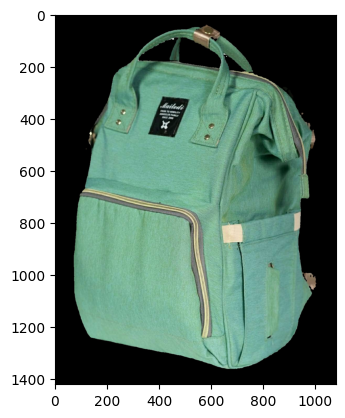

In [18]:
SECOND_PATH_DIR = "/kaggle/input/avitos-my-dataset/kaggle/working/processed_data_dino/11624739720.jpg"
image_bgr = cv2.imread(SECOND_PATH_DIR)
image = Image.fromarray(image_bgr)
plt.imshow(image)

In [41]:
SECOND_PATH_DIR = "/kaggle/input/avitos-my-dataset/kaggle/working/processed_data_dino"
class CustomDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, ids=None, target_mapper=c2l, train=True, cat2l=cat2l):
        if ids is not None:
            self.data_frame = pd.read_csv(csv_file).iloc[ids]
        else:
            self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.target_mapper = target_mapper
        self.train = train
        self.cat2l = cat2l

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        form = '.jpg' if self.train else '.png'
        img_name = os.path.join(self.root_dir, str(self.data_frame.iloc[idx]['id'])+ form)
        img2_name = os.path.join(SECOND_PATH_DIR, str(self.data_frame.iloc[idx]['id'])+ form)
        image = Image.open(img_name).convert('RGB')
        try:
            image_bgr = cv2.imread(img2_name)
            image2 = Image.fromarray(image_bgr)
        except:
            image2 = image
        if self.train:
            label = self.target_mapper[self.data_frame.iloc[idx]['target']]
        else:
            label = 0
        
        if self.transform:
            image = self.transform(image)
            image2 = self.transform(image2)
        
        return {'inputs': image, 
                'inputs2': image2,
                'label': label,
               'category': cat2l[self.data_frame.iloc[idx]['category']]}

def get_dataloaders(base_dir, batch_size=32):
    train_csv = os.path.join(base_dir, 'train_data.csv')
    test_csv = os.path.join(base_dir, 'test_data.csv')
    train_dir = os.path.join(base_dir, 'train_data')
    test_dir = os.path.join(base_dir, 'test_data')
    
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    
    train_dataset = CustomDataset(train_csv, train_dir, transform=train_transform)
    test_dataset = CustomDataset(test_csv, test_dir, transform=test_transform, train=False)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)
    
    return train_loader, test_loader

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split

def split_dataset(csv_file, test_size=0.2, random_state=42):
    # Загрузить данные из CSV
    data = pd.read_csv(csv_file)
    
    # Разделить индексы на обучающие и тестовые
    train_indices, test_indices = train_test_split(
        data.index, test_size=test_size, random_state=random_state
    )
    
    return train_indices, test_indices


In [43]:
train_csv = os.path.join(base_dir, 'train_data.csv')
test_csv = os.path.join(base_dir, 'test_data.csv')
train_dir = os.path.join(base_dir, 'train_data')
test_dir = os.path.join(base_dir, 'test_data')
train_ids, val_ids = split_dataset(train_csv, test_size=0.1)
train_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomRotation(10),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

train_dataset = CustomDataset(train_csv, train_dir, transform=train_transform, ids=train_ids[:20000])
val_dataset = CustomDataset(train_csv, train_dir, transform=test_transform, ids=val_ids[:2000])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


In [47]:
def train_one_epoch(model, train_dataloader, criterion, optimizer, scaler, device="cuda:0"):
    model.train()
    total_loss = 0
    total_accuracy = 0
    n_batchs = 0
    for batch in tqdm(train_dataloader):
        optimizer.zero_grad()
        X_batch, category_batch, y_batch = batch['inputs'].to(device), batch['inputs2'].to(device), batch['label'].to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            y_preds = model(X_batch, category_batch) 
            loss = criterion(y_preds, y_batch)
            total_loss += loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_accuracy += f1_score(y_batch.cpu().numpy(), torch.argmax(y_preds, dim=-1).detach().cpu().numpy(),average='macro')
        n_batchs += 1
    total_accuracy /= n_batchs
    total_loss /= n_batchs
    return total_accuracy, total_loss

def predict(model, val_dataloader, criterion, device="cuda:0"):
    model.eval()
    predicted_classes = torch.tensor([])
    true_classes = torch.tensor([])
    total_loss = 0
    n_batchs = 0
    with torch.no_grad():
        for batch in val_dataloader:
            X_batch, category_batch, y_batch = batch['inputs'].to(device), batch['inputs2'].to(device), batch['label'].to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                y_preds = model(X_batch, category_batch) 
                total_loss += criterion(y_preds, y_batch)
                y_batch = y_batch.cpu()
                predicts = model(X_batch, category_batch)
                predicts = torch.argmax(predicts, dim=1).cpu()
                predicted_classes = torch.cat((predicted_classes, predicts), dim=-1)
                true_classes = torch.cat((true_classes, y_batch), dim=-1)
                n_batchs += 1
    total_loss /= n_batchs
    return total_loss, predicted_classes.numpy(), true_classes.numpy()

def train(model, train_dataloader, val_dataloader, criterion, optimizer, scaler, lr_scheduler, device="cuda:0", n_epochs=10):
    model.to(device)
    for epoch in tqdm(range(n_epochs)):
        train_acc, train_loss = train_one_epoch(model, train_dataloader, criterion, optimizer, scaler, device=device)
        if lr_scheduler is not None: 
            lr_scheduler.step()
        val_loss, predicted_classes, true_classes = predict(model, val_dataloader, criterion, device=device)
        val_acc = f1_score(true_classes, predicted_classes,average='macro')
        print(f'Train Loss:{train_loss} Train F1:{train_acc}')
        print(f'Val Loss:{val_loss} Val F1:{val_acc} ')
        del true_classes, predicted_classes

In [48]:
import warnings
warnings.filterwarnings("ignore")

In [49]:
class CustomModel(nn.Module):
    def __init__(self, cv_encoder, text_encoder, hidden_size=512, num_classes=len(c2l)):
        super().__init__()
        self.cv_encoder = cv_encoder
        self.text_encoder = text_encoder
        self.classifier = nn.Linear(2 * hidden_size, num_classes)
    def forward(self, x, text):
        cv_encoded = self.cv_encoder(x).squeeze(-1).squeeze(-1)
        text_encoded = self.text_encoder(text).squeeze(-1).squeeze(-1)
        
        # Печать шейпов
        # print("Shape of cv_encoded:", cv_encoded.shape)
        # print("Shape of text_encoded:", text_encoded.shape)
        
        concatenated = torch.cat([cv_encoded, text_encoded], dim=1)
        
        # Печать шейпа после конкатенации
        # print("Shape of concatenated:", concatenated.shape)
        
        return self.classifier(concatenated)
        

In [ ]:
from torchvision.models import resnext101_32x8d, resnet18
resnet = resnet18(pretrained=True)
cv_encoder = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet2 = resnet18(pretrained=True)
text_encoder = torch.nn.Sequential(*list(resnet2.children())[:-1])
model = CustomModel(cv_encoder, text_encoder)
model.to(device)
criterion = nn.CrossEntropyLoss()
madgrad_params={
    "params":model.parameters(),
    "lr": 1e-5,
}
scaler = torch.cuda.amp.GradScaler()
n_epochs = 10
optimizer = optim.AdamW(model.parameters(), lr=5e-5)
scheduler_params={
    "optimizer":optimizer,
    "T_max": n_epochs,
    "last_epoch":-1, 
    "verbose":False
    
}
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(**scheduler_params)
train(model, train_loader, val_loader, criterion, optimizer, scaler, lr_scheduler, device="cuda:0",n_epochs=n_epochs)
total_loss, predicted_classes, true_classes = predict(model, val_loader, criterion)


In [ ]:
torch.cuda.empty_cache()